# EDA

I am going to explode

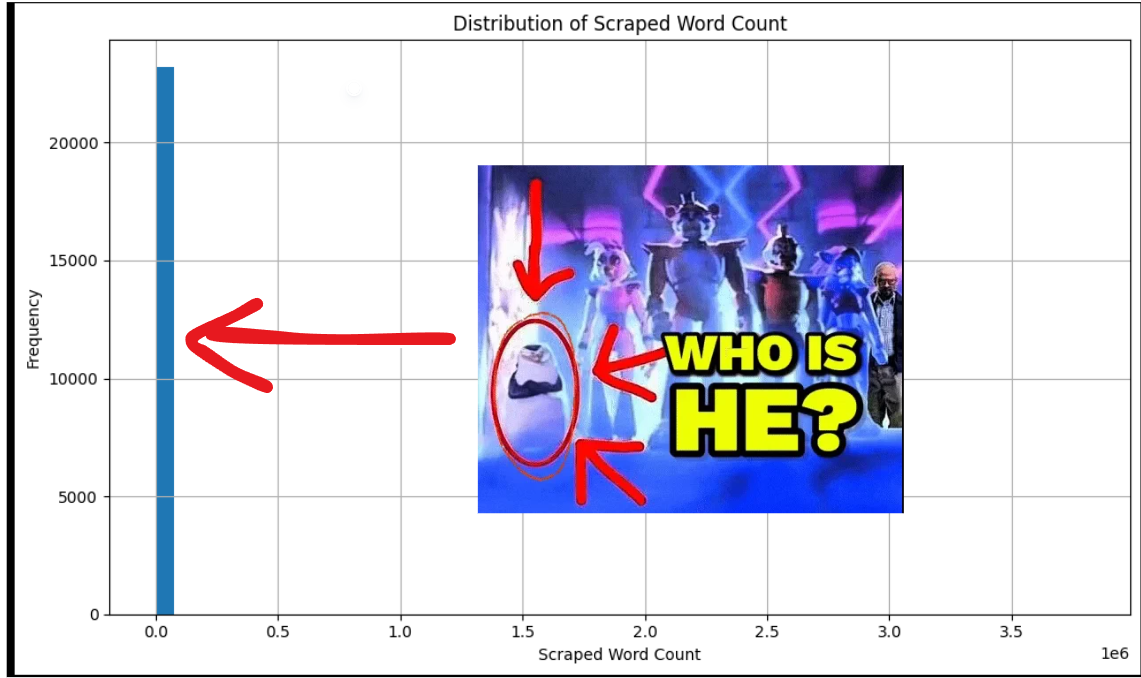

## Dataset Summary and Key Takeaways

The dataset contains **23,196 total rows** and **15 columns**, including article metadata, scraped text fields, scrape status information, and basic engineered features such as title length, scraped text length, and missing-value indicators.

One of the most important findings is that the dataset is **not perfectly complete**. The `news_url`, `source_domain`, and `fixed_url` columns are each missing **330 values**, meaning a small portion of records had no usable URL information. More importantly, `scraped_text` is missing for **9,086 rows**, and `scraped_words` is missing for **13,351 rows**, which shows that a large portion of the scraping process either failed, returned no useful article text, or produced incomplete extracted content.

The target variable, `real`, has no missing values, which is good for modeling because every row still has a fake/real label. However, the class distribution is uneven: the mean of `real` is about **0.75**, meaning roughly **75% of the dataset is labeled real** and **25% is labeled fake**. This class imbalance matters because a model could appear accurate by mostly predicting the majority class.

The `scraped_word_count` column shows major quality issues. While the median article has only **258 words** and the 75th percentile is **672 words**, the maximum value is **3,795,048 words** (what). This means the column contains extreme outliers that are not normal news articles. These outliers likely come from PDFs, government documents, congressional bills, archive pages, transcripts, or large reference pages that were scraped as if they were articles.

Because of these extreme word-count outliers, raw histograms of `scraped_word_count` are misleading. The massive maximum value stretches the x-axis so far that normal articles become nearly invisible. For visualization and modeling, it is better to either use a log-scale plot or filter to a reasonable article range, such as **100 to 5,000 words**.

The top scraped-word-count rows confirm the outlier problem. The largest entries come from sources like `docs.daviecountync.gov`, `posteitaliane.it`, `cdc.gov`, `wikiquote.org`, `gpo.gov`, and `census.gov`. These are not typical short-form news articles, so they should be treated carefully or removed from the model-ready dataset.

Overall, the dataset is usable, but it needs cleaning before modeling. The most important steps are removing failed scrapes, handling missing text, filtering extreme scraped-word-count outliers, and accounting for class imbalance between fake and real articles.

In [6]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split    
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
import requests
import re
import time
from tqdm.notebook import tqdm
from urllib.parse import urlparse
# Load the dataset
df = pd.read_csv('FakeNewsNet_scraped_FIXED.csv')
#gitignore!!!
import os

# Preliminary Checks

In [10]:
df.head()
display(df.info())
display(df.describe())
display(df.isnull().sum())

print(df["scraped_word_count"].describe())

print(
    df[["title", "news_url", "source_domain", "scraped_word_count", "scrape_status"]]
    .sort_values("scraped_word_count", ascending=False)
    .head(20)
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 23196 non-null  object 
 1   news_url              22866 non-null  object 
 2   source_domain         22866 non-null  object 
 3   tweet_num             23196 non-null  int64  
 4   real                  23196 non-null  int64  
 5   scraped_text          14110 non-null  object 
 6   scraped_words         9845 non-null   object 
 7   scraped_word_count    23196 non-null  float64
 8   scrape_status         23196 non-null  object 
 9   fixed_url             22866 non-null  object 
 10  status_group          23196 non-null  object 
 11  title_length          23196 non-null  int64  
 12  scraped_text_length   23196 non-null  int64  
 13  news_url_missing      23196 non-null  bool   
 14  scraped_text_missing  23196 non-null  bool   
dtypes: bool(2), float64

None

,tweet_num,real,scraped_word_count,title_length,scraped_text_length
count,23196.000000,23196.000000,2.319600e+04,23196.000000,2.319600e+04
mean,88.956803,0.751897,1.161880e+03,68.303328,5.824010e+03
std,488.694592,0.431921,2.545887e+04,23.287987,1.893385e+04
min,0.000000,0.000000,0.000000e+00,10.000000,0.000000e+00
25%,11.000000,1.000000,0.000000e+00,55.000000,0.000000e+00
50%,37.000000,1.000000,2.580000e+02,68.000000,1.532000e+03
75%,65.000000,1.000000,6.720000e+02,84.000000,3.931000e+03
max,29060.000000,1.000000,3.795048e+06,340.000000,1.344099e+06


title                       0
news_url                  330
source_domain             330
tweet_num                   0
real                        0
scraped_text             9086
scraped_words           13351
scraped_word_count          0
scrape_status               0
fixed_url                 330
status_group                0
title_length                0
scraped_text_length         0
news_url_missing            0
scraped_text_missing        0
dtype: int64

count    2.319600e+04
mean     1.161880e+03
std      2.545887e+04
min      0.000000e+00
25%      0.000000e+00
50%      2.580000e+02
75%      6.720000e+02
max      3.795048e+06
Name: scraped_word_count, dtype: float64
                                                   title  \
8005   Elsa Hosk Takes the E!Q in 42—and Just Try Not...   
19768  Cop Celebrates 9th Anniversary  Reaffirms Comm...   
13230         Centers for Disease Control and Prevention   
6055                                       Elvis Presley   
4364                          Browse Congressional Bills   
10154                         Browse Congressional Bills   
9615   the Border Security Economic Opportunity and I...   
17076  Health Insurance Coverage in the United States...   
6311   Who Benefits from President Trump’s Child Care...   
21416  Mike G.: After high school in the '60s I worke...   
18165  Text of H.R. 3338 (107th): Department of Defen...   
9184                                          Last words   
230

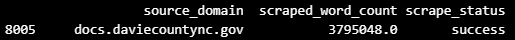

```bash
uh...

```

Status Group Counts:
status_group
success                14821
other_request_error     5321
request_error_404       2252
request_timeout          472
missing_url              330
Name: count, dtype: int64


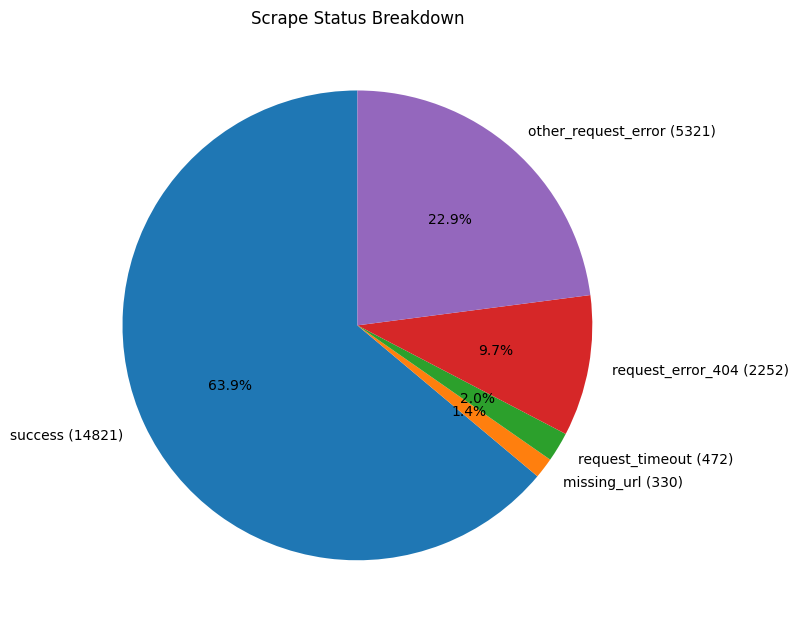

C:\Users\ryan1\AppData\Local\Temp\ipykernel_21120\370957972.py:91: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


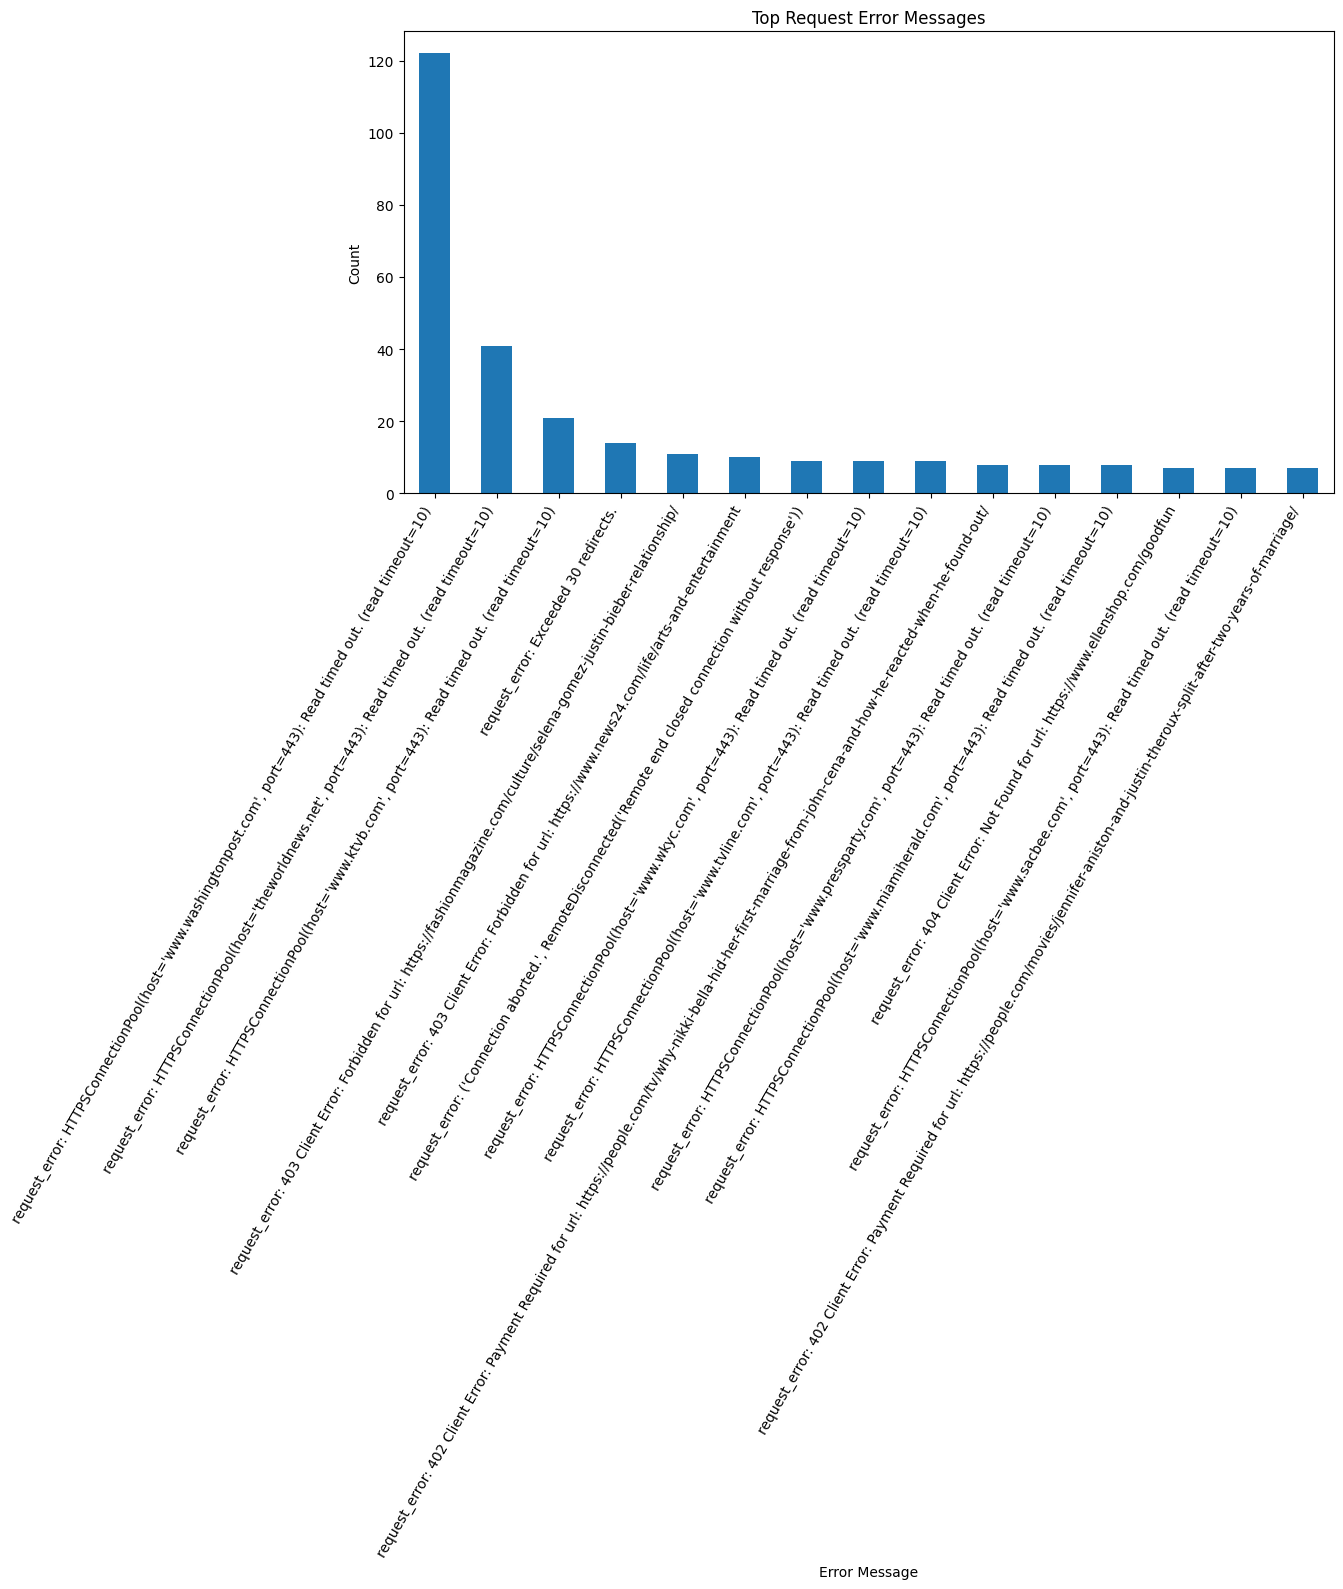

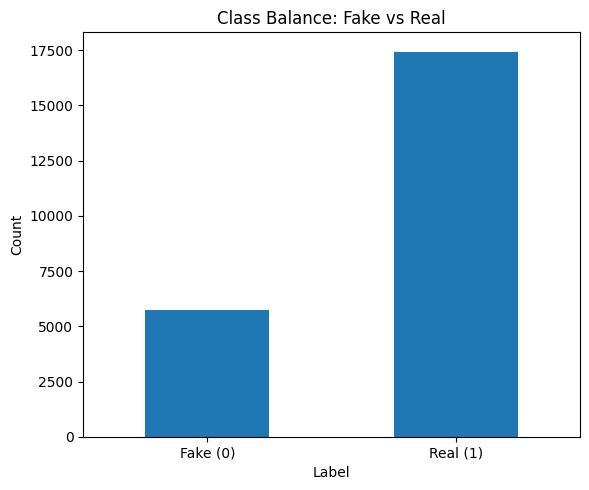

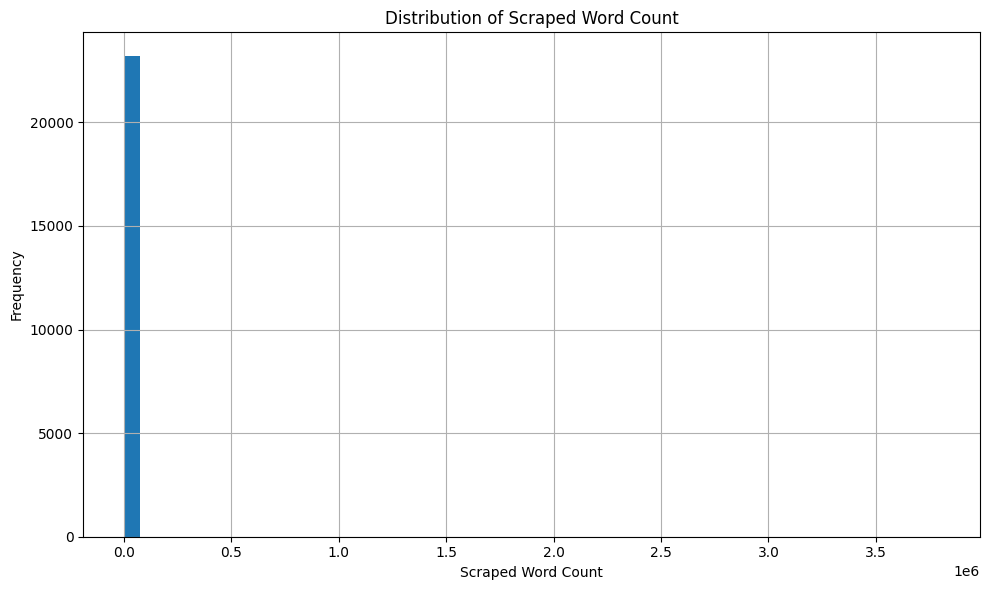

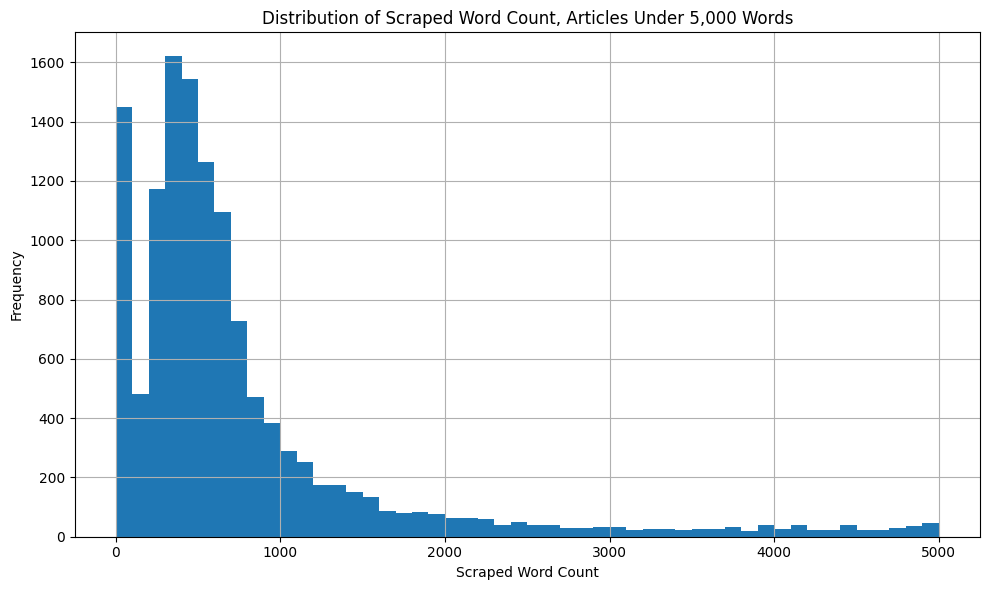

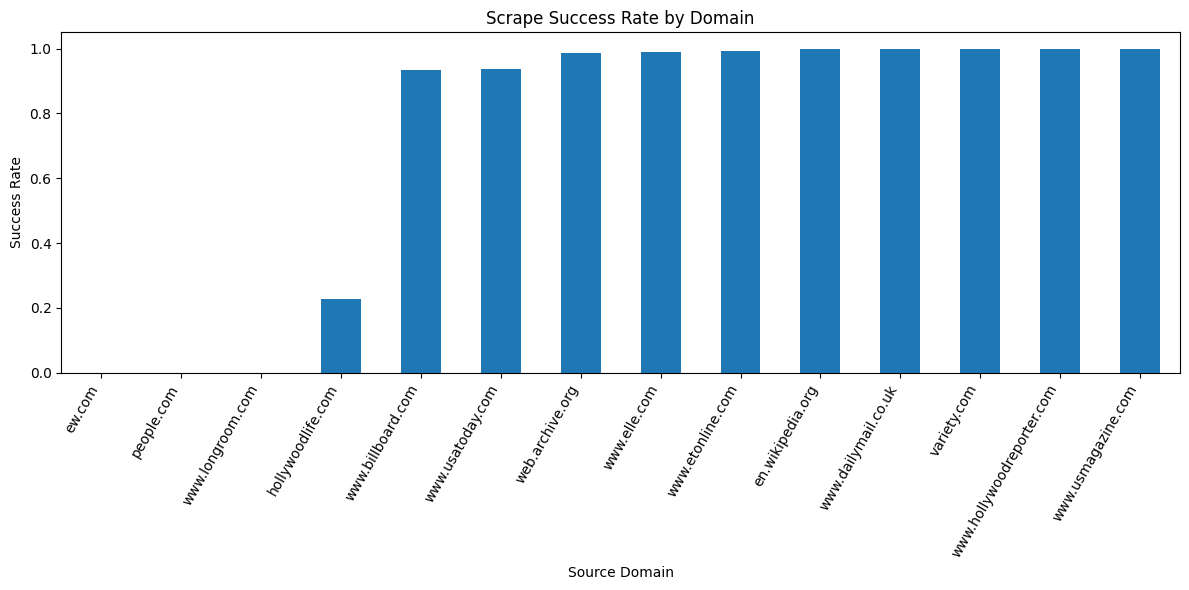

Hilarious that most of our data was from people.com and the success rate was absolutely abysmal. I guess they have some sort of bot protection or something.


In [11]:
# add some cool rows to the df to display later in the graphs
df["title_length"] = df["title"].fillna("").astype(str).str.len()
df["scraped_text_length"] = df["scraped_text"].fillna("").astype(str).str.len()

df["news_url_missing"] = (
    df["news_url"].isna()
    | (df["news_url"].astype(str).str.strip() == "")
)

df["scraped_text_missing"] = (
    df["scraped_text"].isna()
    | (df["scraped_text"].astype(str).str.strip() == "")
)



# Status Grouping
# ============================================================

# copied from fixer
def status_group(john_hellyah):
    s = str(john_hellyah).lower().strip()
    if s == "success":
        return "success"
    if "missing_url" in s:
        return "missing_url"
    if "timeout" in s or "read timed out" in s:
        return "request_timeout"
    if "404" in s:
        return "request_error_404"
    if "request_error" in s:
        return "other_request_error"
    return "other"


# catchass sorry catchall
if "status_group" not in df.columns:
    df["status_group"] = df["scrape_status"].apply(status_group)

print("Status Group Counts:")
print(df["status_group"].value_counts(dropna=False))


# Graph 1: Scrape Status Breakdown
# =================================================================================================================

status_order = [
    "success",
    "missing_url",
    "request_timeout",
    "request_error_404",
    "other_request_error",
    "other"
]

status_counts = df["status_group"].value_counts().reindex(status_order, fill_value=0)
nonzero = status_counts[status_counts > 0]

labels = [f"{status} ({count})" for status, count in nonzero.items()]

plt.figure(figsize=(8, 8))
plt.pie(
    nonzero.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Scrape Status Breakdown")
plt.tight_layout()
plt.show()



# Graph 2: Top Request Error Messages
# ===============================================================

error_rows = df[
    df["scrape_status"]
    .astype(str)
    .str.contains("request_error", case=False, na=False)
]

top_errors = error_rows["scrape_status"].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_errors.plot(kind="bar")
plt.title("Top Request Error Messages")
plt.xlabel("Error Message")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


# Graph 3: Class Balance
# ==============================

df["real"] = pd.to_numeric(df["real"], errors="coerce")

plt.figure(figsize=(6, 5))
df["real"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Balance: Fake vs Real")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Fake (0)", "Real (1)"], rotation=0)
plt.tight_layout()
plt.show()



# Graph 4: Scraped Word Count Distribution
# =======================================================================================================

df["scraped_word_count"] = pd.to_numeric(
    df["scraped_word_count"],
    errors="coerce"
)

plt.figure(figsize=(10, 6))
df["scraped_word_count"].dropna().hist(bins=50)
plt.title("Distribution of Scraped Word Count")
plt.xlabel("Scraped Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# weird outlier so...

word_counts = df["scraped_word_count"].dropna()

# Remove empty scrapes and extreme outliers for visualization
filtered_word_counts = word_counts[
    (word_counts > 0) &
    (word_counts <= 5000)
]

plt.figure(figsize=(10, 6))
filtered_word_counts.hist(bins=50)
plt.title("Distribution of Scraped Word Count, Articles Under 5,000 Words")
plt.xlabel("Scraped Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# Graph 5: Scrape Success Rate by Domain
# ============================================================

topdawg = (
    df["source_domain"]
    .fillna("missing")
    .value_counts()
    .head(15)
    .index
)

john_domain = df[
    df["source_domain"].fillna("missing").isin(topdawg)
].copy()

john_domain["is_success"] = (
    john_domain["scrape_status"]
    .astype(str)
    .str.lower()
    .str.strip()
    .eq("success")
)

success_rate = (
    john_domain
    .groupby("source_domain")["is_success"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 6))
success_rate.plot(kind="bar")
plt.title("Scrape Success Rate by Domain")
plt.xlabel("Source Domain")
plt.ylabel("Success Rate")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

print("Hilarious that most of our data was from people.com and the success rate was absolutely abysmal. I guess they have some sort of bot protection or something.")

In [12]:
# clean the data for modeling and save to new CSV
output_file = "FakeNewsNet_scraped_MODEL_READY.csv"


df["scrape_status"] = df["scrape_status"].astype(str).str.lower().str.strip()
df["scraped_text"] = df["scraped_text"].fillna("").astype(str).str.strip()
df["scraped_word_count"] = pd.to_numeric(df["scraped_word_count"], errors="coerce")

print("Original rows:", len(df))

clean_df = df[
    (df["scrape_status"] == "success") &
    (df["scraped_text"] != "") &
    (df["scraped_word_count"] >= 10) &
    (df["scraped_word_count"] <= 50000)
].copy()

print("Rows after cleaning:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

clean_df.to_csv(output_file, index=False)

print("Saved cleaned file as:", output_file)

Original rows: 23196
Rows after cleaning: 13987
Rows removed: 9209
Saved cleaned file as: FakeNewsNet_scraped_MODEL_READY.csv
